# Grands Tests — Phase 2 : NNH + 2-opt (1000 instances par taille)

---

> **Objectif**  
> Valider la robustesse statistique des résultats obtenus sur 30 instances  
> en les reproduisant sur **1000 instances par taille** (5 000 instances au total).  
> La dernière section compare directement les deux échantillons.

---

## Table des matières
1. [Génération des données](#1)
2. [Chargement & Statistiques descriptives](#2)
3. [Boxplots — Dispersion par taille](#3)
4. [Histogrammes — Distribution des coûts et des temps](#4)
5. [Évolution — Scalabilité en fonction de n](#5)
6. [Corrélations — Relations entre variables](#6)
7. [Comparaison 30 vs 1000 instances](#7)

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', '..', 'Phase 4'))
sys.path.insert(0, os.path.join('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

TAILLES    = [10, 20, 50, 100, 200]
N_RUNS     = 1000
CSV_1000   = os.path.join('resultats_nnh_1000.csv')
CSV_30     = os.path.join('..', 'resultats', 'resultats_nnh.csv')
FIG_DIR    = os.path.join('figures')
os.makedirs(FIG_DIR, exist_ok=True)

PALETTE    = sns.color_palette('Blues_d', len(TAILLES))
PALETTE_N  = dict(zip(TAILLES, PALETTE))

def sauvegarder(fig, nom):
    fig.savefig(os.path.join(FIG_DIR, nom), bbox_inches='tight')

print('Librairies chargees.')

Librairies chargees.


---
<a id='1'></a>
## 1. Génération des données

On lance **1000 seeds × 5 tailles = 5 000 instances** via `resoudre_heuristique()`.  
Si le CSV existe déjà, on le recharge directement (évite de relancer 5 000 solveurs).

In [2]:
from preprocess import generate_instance
from heuristique import resoudre_heuristique
import time

if os.path.exists(CSV_1000):
    print(f'CSV deja present ({CSV_1000}), chargement...')
    df = pd.read_csv(CSV_1000)
    print(f'  {len(df)} lignes chargees.')
else:
    print(f'Generation de {N_RUNS} x {len(TAILLES)} = {N_RUNS*len(TAILLES)} instances...')
    lignes = []
    t_debut = time.time()

    for n in TAILLES:
        t_n = time.time()
        for seed in range(N_RUNS):
            inst = generate_instance(n=n, seed=seed)
            _, cout, stats_run = resoudre_heuristique(inst)
            lignes.append({
                'methode'       : 'NNH+2opt',
                'n'             : n,
                'seed'          : seed,
                'cout'          : round(cout, 2),
                'cout_initial'  : round(stats_run['cout_initial'], 2),
                'gain_pct'      : stats_run['gain_2opt_pct'],
                'temps_total'   : stats_run['temps_total'],
                'n_vehicules'   : stats_run['n_vehicules_utilises'],
                'n_infaisables' : stats_run['n_clients_infaisables'],
                'valide'        : stats_run['valide'],
            })
        print(f'  n={n:>3} : {N_RUNS} runs en {time.time()-t_n:.1f}s')

    df = pd.DataFrame(lignes)
    df.to_csv(CSV_1000, index=False)
    print(f'\nCSV sauvegarde : {CSV_1000}')
    print(f'Temps total : {time.time()-t_debut:.1f}s')

df['valide'] = df['valide'].astype(str).str.strip().str.lower() == 'true'
print(f'\nInstances : {len(df)} lignes')
print(f'Tailles   : {sorted(df["n"].unique())}')
print(f'Valides   : {df["valide"].mean()*100:.1f}%')
df.head()

CSV deja present (resultats_nnh_1000.csv), chargement...
  5000 lignes chargees.

Instances : 5000 lignes
Tailles   : [np.int64(10), np.int64(20), np.int64(50), np.int64(100), np.int64(200)]
Valides   : 100.0%


,methode,n,seed,cout,cout_initial,gain_pct,temps_total,n_vehicules,n_infaisables,valide
0,NNH+2opt,10,0,702.64,702.64,0.00,0.0001,5,0,True
1,NNH+2opt,10,1,522.34,522.34,0.00,0.0001,4,0,True
2,NNH+2opt,10,2,432.44,433.52,0.25,0.0001,3,0,True
3,NNH+2opt,10,3,457.14,457.14,0.00,0.0001,4,0,True
4,NNH+2opt,10,4,488.96,488.96,0.00,0.0001,3,0,True


---
<a id='2'></a>
## 2. Chargement & Statistiques descriptives

In [3]:
def tableau_stats(df, variable, nom_affiche):
    tbl = df.groupby('n')[variable].agg(
        Moyenne    = 'mean',
        Ecart_type = 'std',
        Variance   = 'var',
        Mediane    = 'median',
        Min        = 'min',
        Max        = 'max',
    ).round(4)
    print(f'\n=== {nom_affiche} ===')
    display(tbl)
    return tbl

tbl_cout  = tableau_stats(df, 'cout',        'COUT TOTAL (1000 instances)')
tbl_temps = tableau_stats(df, 'temps_total', 'TEMPS DE CALCUL (s)')
tbl_veh   = tableau_stats(df, 'n_vehicules', 'NOMBRE DE VEHICULES')
tbl_gain  = tableau_stats(df, 'gain_pct',    'GAIN 2-OPT (%)')


=== COUT TOTAL (1000 instances) ===


,Moyenne,Ecart_type,Variance,Mediane,Min,Max
n,,,,,,
10,506.6863,72.1518,5205.8871,507.490,291.54,755.24
20,805.1544,96.7321,9357.1017,800.650,506.86,1171.34
50,1516.9495,128.7784,16583.8825,1515.360,1154.18,1964.56
100,2431.4905,162.3321,26351.7185,2429.295,1942.91,2945.70
200,3878.8222,188.4234,35503.3905,3882.760,3215.84,4456.10



=== TEMPS DE CALCUL (s) ===


,Moyenne,Ecart_type,Variance,Mediane,Min,Max
n,,,,,,
10,0.0001,0.0001,0.0,0.0001,0.0001,0.0040
20,0.0003,0.0001,0.0,0.0003,0.0003,0.0012
50,0.0016,0.0003,0.0,0.0016,0.0013,0.0064
100,0.0057,0.0006,0.0,0.0056,0.0049,0.0121
200,0.0206,0.0016,0.0,0.0202,0.0180,0.0347



=== NOMBRE DE VEHICULES ===


,Moyenne,Ecart_type,Variance,Mediane,Min,Max
n,,,,,,
10,3.465,0.5595,0.3131,3.0,3,5
20,4.723,0.7981,0.6369,5.0,3,7
50,8.343,0.9551,0.9123,8.0,6,12
100,13.432,1.1674,1.3627,13.0,10,17
200,22.027,1.3229,1.7500,22.0,19,26



=== GAIN 2-OPT (%) ===


,Moyenne,Ecart_type,Variance,Mediane,Min,Max
n,,,,,,
10,0.2607,0.8819,0.7778,0.00,0.0,8.95
20,0.5006,1.0117,1.0236,0.00,0.0,6.65
50,0.7148,0.8290,0.6872,0.44,0.0,4.82
100,0.7109,0.6065,0.3678,0.57,0.0,3.80
200,0.7329,0.4463,0.1992,0.65,0.0,2.41


---
<a id='3'></a>
## 3. Boxplots — Dispersion par taille

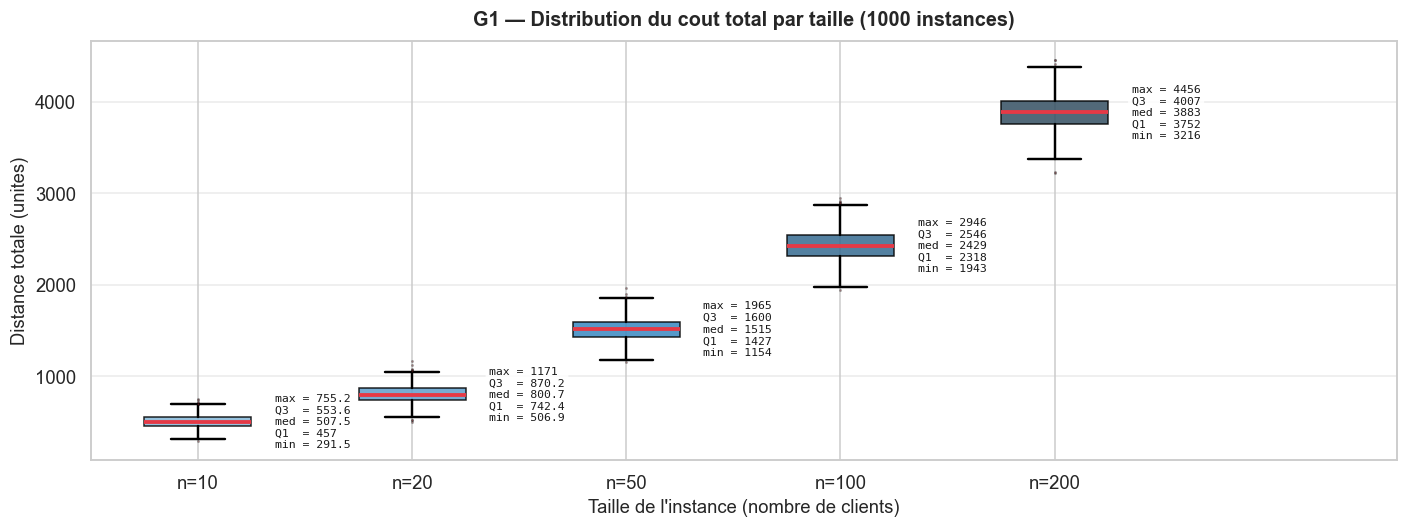

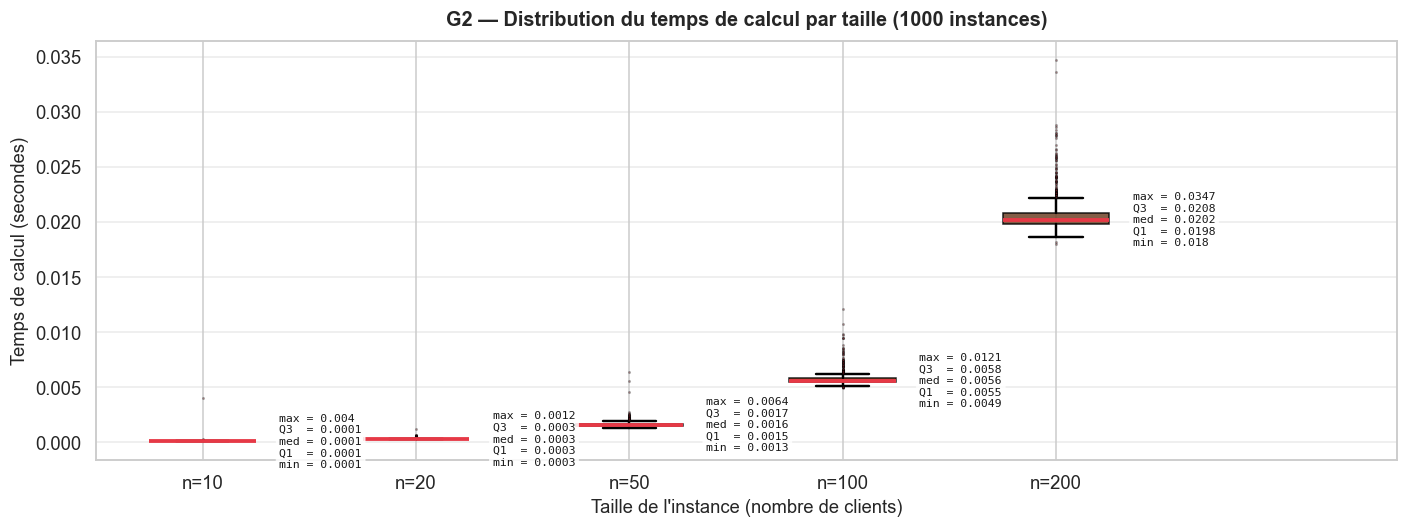

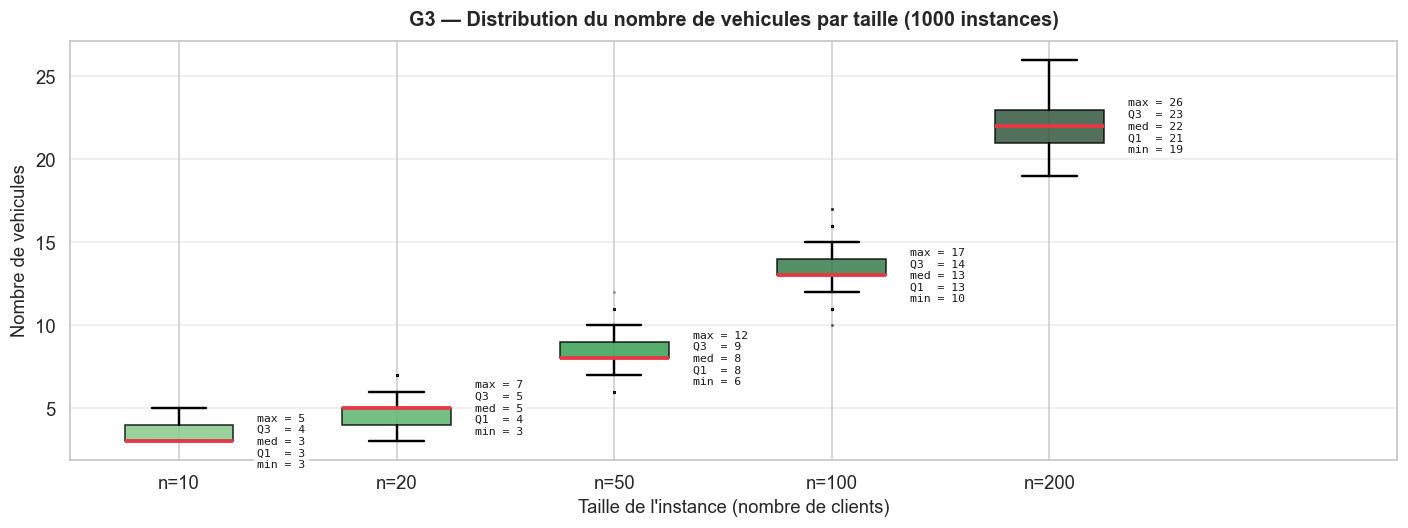

In [4]:
def boxplot_metrique(df, variable, ylabel, titre, fname, couleur):
    fig, ax = plt.subplots(figsize=(13, 5))

    data = [df[df['n'] == n][variable].values for n in TAILLES]
    bp   = ax.boxplot(
        data,
        tick_labels  = [f'n={n}' for n in TAILLES],
        patch_artist = True,
        medianprops  = {'color': '#e63946', 'linewidth': 2.5},
        whiskerprops = {'linewidth': 1.6},
        capprops     = {'linewidth': 1.6},
        flierprops   = {'marker': '.', 'markersize': 2,
                        'markerfacecolor': '#e63946', 'alpha': 0.3},
    )
    shades = sns.color_palette(couleur, len(TAILLES))
    for patch, col in zip(bp['boxes'], shades):
        patch.set_facecolor(col)
        patch.set_alpha(0.85)

    # Annotations statistiques (min / Q1 / med / Q3 / max)
    for i, n in enumerate(TAILLES):
        y   = df[df['n'] == n][variable].values
        mn  = y.min()
        q1  = np.percentile(y, 25)
        med = np.median(y)
        q3  = np.percentile(y, 75)
        mx  = y.max()
        txt = (f'max = {mx:.4g}\n'
               f'Q3  = {q3:.4g}\n'
               f'med = {med:.4g}\n'
               f'Q1  = {q1:.4g}\n'
               f'min = {mn:.4g}')
        ax.text(i + 1 + 0.36, med, txt,
                fontsize=7.5, va='center', ha='left',
                family='monospace', color='#1a1a1a',
                bbox=dict(boxstyle='round,pad=0.28', fc='white',
                          alpha=0.85, lw=0.5))

    ax.set_xlabel("Taille de l'instance (nombre de clients)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(titre, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlim(0.5, len(TAILLES) + 1.6)
    ax.grid(True, axis='y', alpha=0.4)
    plt.tight_layout()
    sauvegarder(fig, fname)
    plt.show()

# Note : 1000 points -> pas de jitter (trop dense), les fliers suffisent
boxplot_metrique(df, 'cout',        'Distance totale (unites)',   'G1 — Distribution du cout total par taille (1000 instances)',          'boxplot_cout.png',     'Blues_d')
boxplot_metrique(df, 'temps_total', 'Temps de calcul (secondes)', 'G2 — Distribution du temps de calcul par taille (1000 instances)',     'boxplot_temps.png',    'Oranges_d')
boxplot_metrique(df, 'n_vehicules', 'Nombre de vehicules',        'G3 — Distribution du nombre de vehicules par taille (1000 instances)', 'boxplot_vehicules.png','Greens_d')

---
<a id='4'></a>
## 4. Histogrammes — Distribution des coûts et des temps

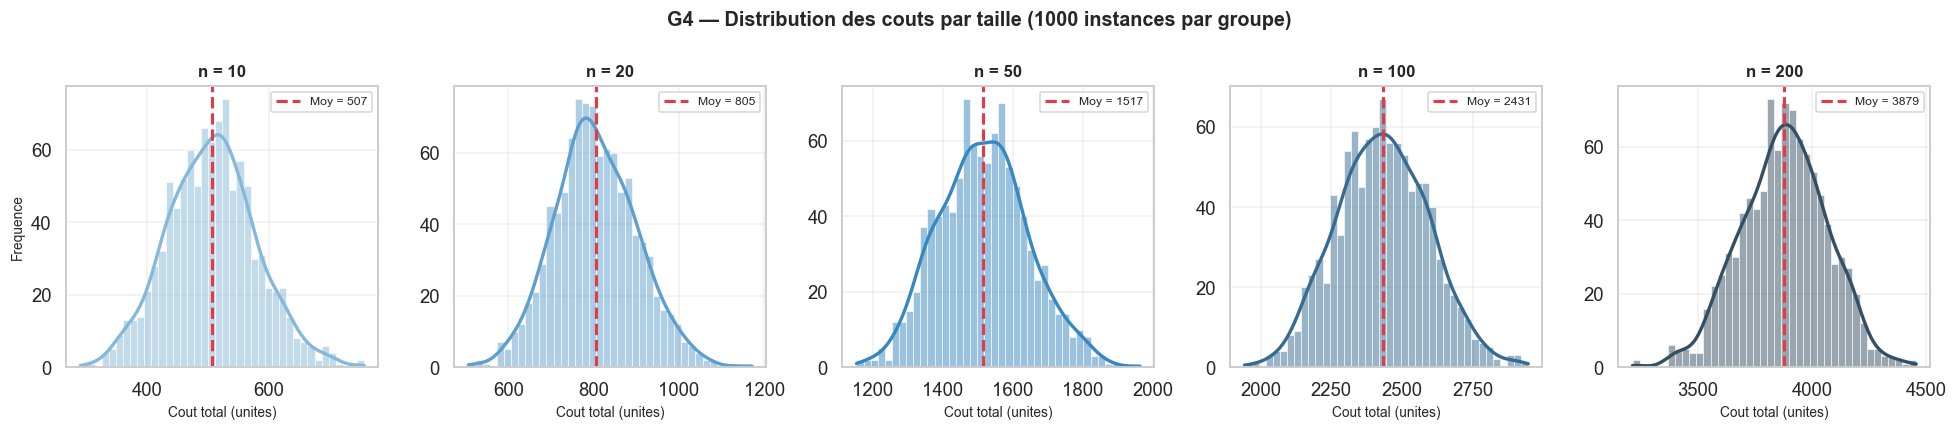

In [5]:
# G4 — Histogramme des couts (1000 instances)
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
fig.suptitle('G4 — Distribution des couts par taille (1000 instances par groupe)',
             fontsize=13, fontweight='bold')

for ax, (n, col) in zip(axes, PALETTE_N.items()):
    valeurs = df[df['n'] == n]['cout'].values
    sns.histplot(valeurs, kde=True, ax=ax, color=col, bins=40,
                 line_kws={'linewidth': 2.2})
    ax.axvline(valeurs.mean(), color='#e63946', linewidth=2,
               linestyle='--', label=f'Moy = {valeurs.mean():.0f}')
    ax.set_title(f'n = {n}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Cout total (unites)', fontsize=9)
    ax.set_ylabel('Frequence' if n == 10 else '', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
sauvegarder(fig, 'histogrammes_cout.png')
plt.show()

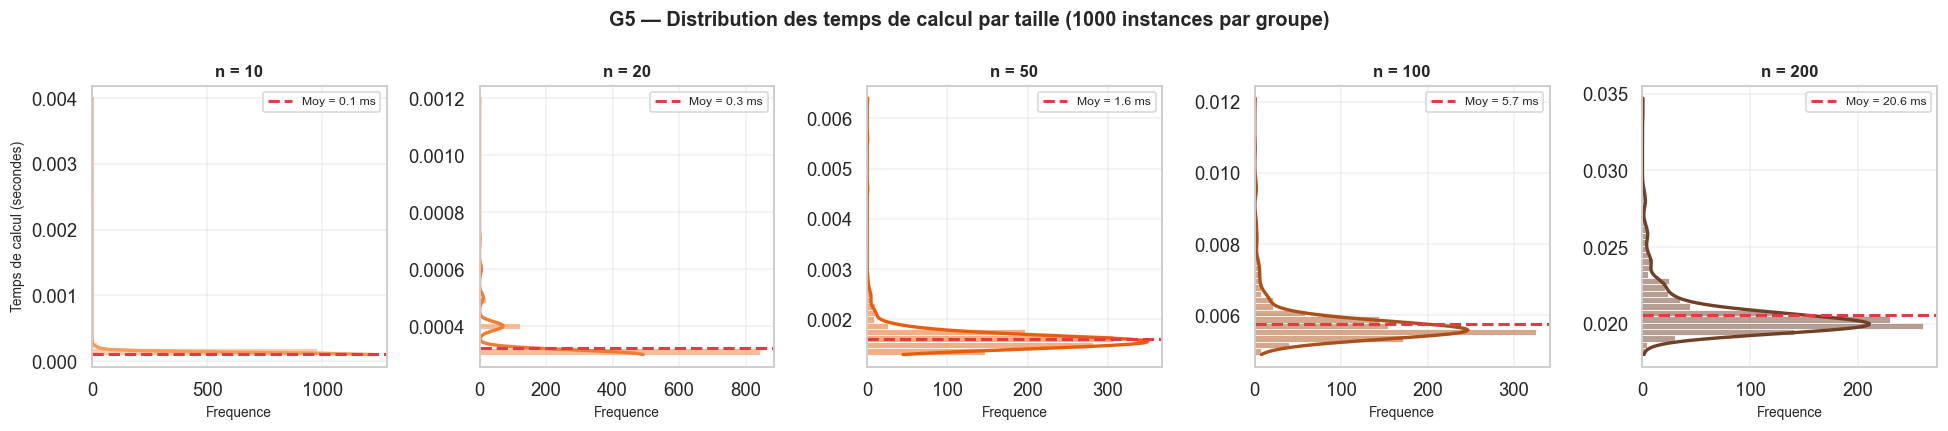

In [6]:
# G5 — Histogramme temps (horizontal, temps en ordonnee)
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=False)
fig.suptitle('G5 — Distribution des temps de calcul par taille (1000 instances par groupe)',
             fontsize=13, fontweight='bold')

palette_orange = sns.color_palette('Oranges_d', len(TAILLES))
for ax, (n, col) in zip(axes, zip(TAILLES, palette_orange)):
    valeurs = df[df['n'] == n]['temps_total'].values
    sns.histplot(y=valeurs, kde=True, ax=ax, color=col, bins=40,
                 line_kws={'linewidth': 2.2})
    ax.axhline(valeurs.mean(), color='#e63946', linewidth=2,
               linestyle='--', label=f'Moy = {valeurs.mean()*1000:.1f} ms')
    ax.set_title(f'n = {n}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Temps de calcul (secondes)' if n == 10 else '', fontsize=9)
    ax.set_xlabel('Frequence', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
sauvegarder(fig, 'histogrammes_temps.png')
plt.show()

---
<a id='5'></a>
## 5. Évolution — Scalabilité en fonction de n

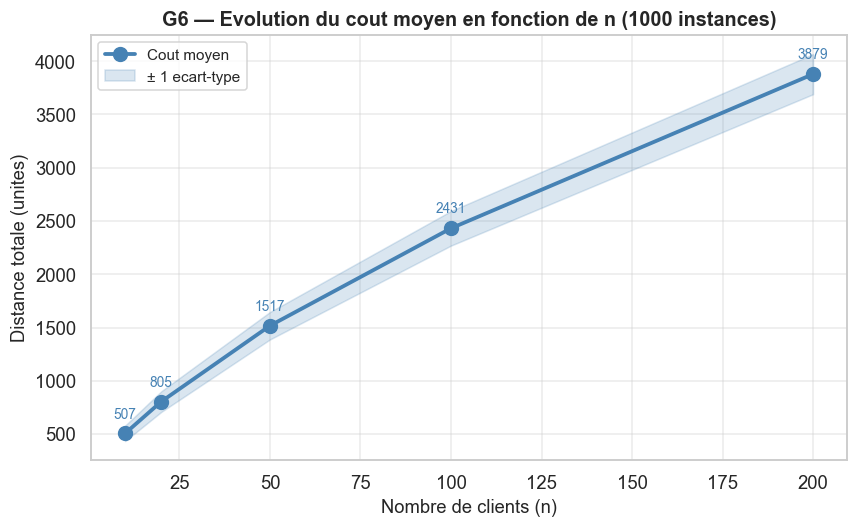

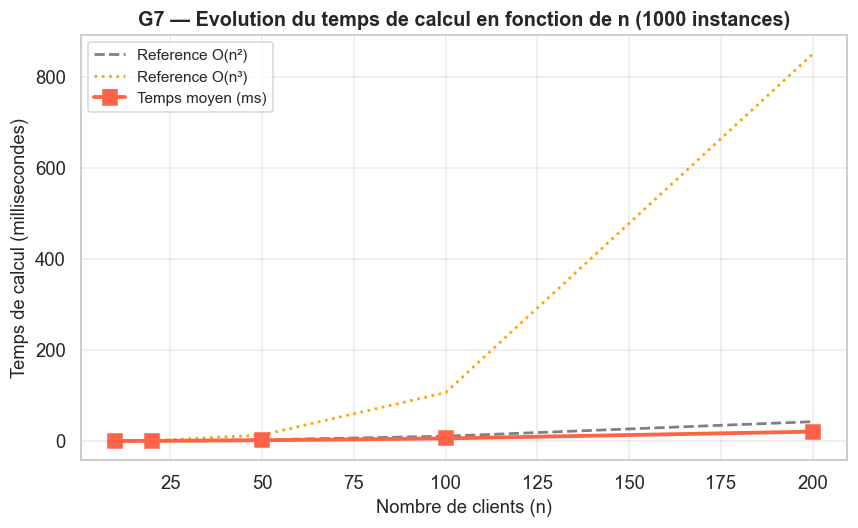

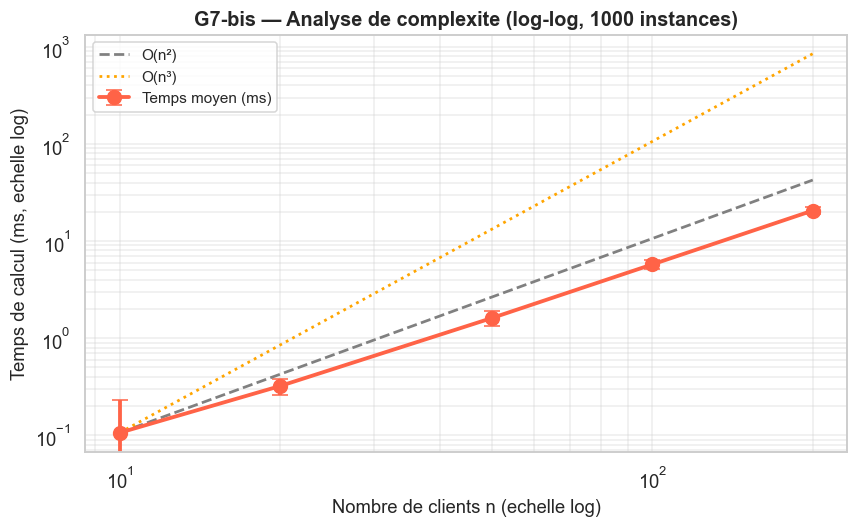

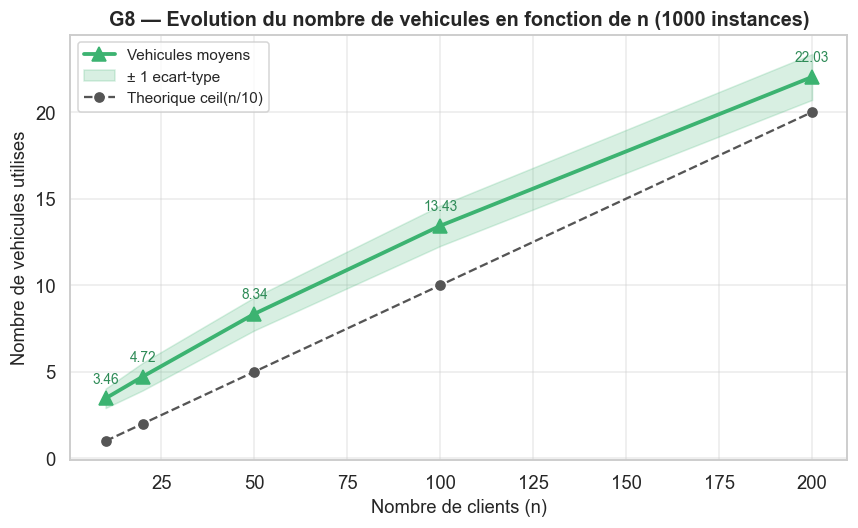

In [7]:
import math

agg = df.groupby('n').agg(
    cout_moy  = ('cout',        'mean'),
    cout_std  = ('cout',        'std'),
    temps_moy = ('temps_total', 'mean'),
    temps_std = ('temps_total', 'std'),
    veh_moy   = ('n_vehicules', 'mean'),
    veh_std   = ('n_vehicules', 'std'),
    gain_moy  = ('gain_pct',    'mean'),
).reset_index()

# G6 — Cout moyen
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(agg['n'], agg['cout_moy'], 'o-', color='steelblue', linewidth=2.5, markersize=9, label='Cout moyen')
ax.fill_between(agg['n'],
                agg['cout_moy'] - agg['cout_std'],
                agg['cout_moy'] + agg['cout_std'],
                alpha=0.2, color='steelblue', label='± 1 ecart-type')
for _, row in agg.iterrows():
    ax.annotate(f"{row['cout_moy']:.0f}",
                xy=(row['n'], row['cout_moy']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='steelblue')
ax.set_xlabel('Nombre de clients (n)', fontsize=12)
ax.set_ylabel('Distance totale (unites)', fontsize=12)
ax.set_title('G6 — Evolution du cout moyen en fonction de n (1000 instances)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
sauvegarder(fig, 'evolution_cout.png')
plt.show()

# G7 — Temps moyen
t0    = agg['temps_moy'].iloc[0]
n0    = float(agg['n'].iloc[0])
n_ref = np.array(TAILLES, dtype=float)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(agg['n'], agg['temps_moy'] * 1000,
            yerr=agg['temps_std'] * 1000,
            fmt='s-', color='tomato', linewidth=2.5,
            markersize=9, capsize=5, label='Temps moyen (ms)')
ax.plot(n_ref, t0 * 1000 * (n_ref / n0) ** 2,
        '--', color='gray',   linewidth=1.8, label='Reference O(n²)')
ax.plot(n_ref, t0 * 1000 * (n_ref / n0) ** 3,
        ':',  color='orange', linewidth=1.8, label='Reference O(n³)')
ax.set_xlabel('Nombre de clients (n)', fontsize=12)
ax.set_ylabel('Temps de calcul (millisecondes)', fontsize=12)
ax.set_title('G7 — Evolution du temps de calcul en fonction de n (1000 instances)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
sauvegarder(fig, 'evolution_temps.png')
plt.show()

# G7-bis — Log-log
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(agg['n'], agg['temps_moy'] * 1000,
            yerr=agg['temps_std'] * 1000,
            fmt='o-', color='tomato', linewidth=2.5,
            markersize=9, capsize=5, label='Temps moyen (ms)')
ax.plot(n_ref, t0 * 1000 * (n_ref / n0) ** 2,
        '--', color='gray',   linewidth=1.8, label='O(n²)')
ax.plot(n_ref, t0 * 1000 * (n_ref / n0) ** 3,
        ':',  color='orange', linewidth=1.8, label='O(n³)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Nombre de clients n (echelle log)', fontsize=12)
ax.set_ylabel('Temps de calcul (ms, echelle log)', fontsize=12)
ax.set_title('G7-bis — Analyse de complexite (log-log, 1000 instances)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.35)
plt.tight_layout()
sauvegarder(fig, 'loglog_temps.png')
plt.show()

# G8 — Vehicules
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(agg['n'], agg['veh_moy'], '^-', color='mediumseagreen',
        linewidth=2.5, markersize=9, label='Vehicules moyens')
ax.fill_between(agg['n'],
                agg['veh_moy'] - agg['veh_std'],
                agg['veh_moy'] + agg['veh_std'],
                alpha=0.2, color='mediumseagreen', label='± 1 ecart-type')
veh_theo = [math.ceil(n / 10) for n in TAILLES]
ax.plot(TAILLES, veh_theo, 'o--', color='#555555', linewidth=1.5,
        markersize=6, label='Theorique ceil(n/10)')
for _, row in agg.iterrows():
    ax.annotate(f"{row['veh_moy']:.2f}",
                xy=(row['n'], row['veh_moy']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='seagreen')
ax.set_xlabel('Nombre de clients (n)', fontsize=12)
ax.set_ylabel('Nombre de vehicules utilises', fontsize=12)
ax.set_title('G8 — Evolution du nombre de vehicules en fonction de n (1000 instances)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
sauvegarder(fig, 'evolution_vehicules.png')
plt.show()

---
<a id='6'></a>
## 6. Corrélations — Relations entre variables

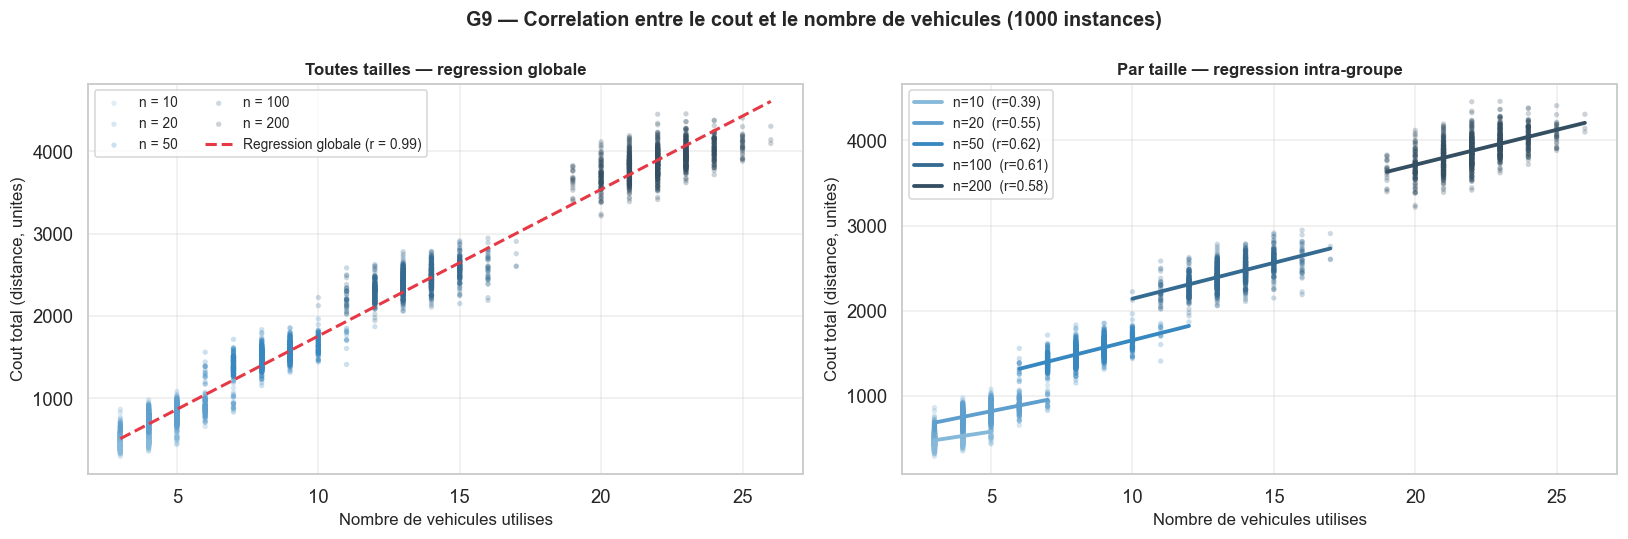

In [8]:
# G9 — Scatter cout vs n_vehicules
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('G9 — Correlation entre le cout et le nombre de vehicules (1000 instances)',
             fontsize=13, fontweight='bold')

# Sous-graphe gauche : toutes tailles
ax = axes[0]
for n in TAILLES:
    sub = df[df['n'] == n]
    ax.scatter(sub['n_vehicules'], sub['cout'],
               color=PALETTE_N[n], alpha=0.25, s=12, label=f'n = {n}',
               edgecolors='none')
sl, ic, r, _, _ = stats.linregress(df['n_vehicules'], df['cout'])
xr = np.linspace(df['n_vehicules'].min(), df['n_vehicules'].max(), 200)
ax.plot(xr, sl * xr + ic, '--', color='#e63946', linewidth=2,
        label=f'Regression globale (r = {r:.2f})')
ax.set_xlabel('Nombre de vehicules utilises', fontsize=11)
ax.set_ylabel('Cout total (distance, unites)', fontsize=11)
ax.set_title('Toutes tailles — regression globale', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.35)

# Sous-graphe droit : regression intra-groupe
ax2 = axes[1]
for n, col in zip(TAILLES, PALETTE):
    sub = df[df['n'] == n].copy()
    ax2.scatter(sub['n_vehicules'], sub['cout'],
                color=col, alpha=0.25, s=12, edgecolors='none')
    if sub['n_vehicules'].nunique() > 1:
        sl2, ic2, r2, _, _ = stats.linregress(sub['n_vehicules'], sub['cout'])
        xv = np.linspace(sub['n_vehicules'].min(), sub['n_vehicules'].max(), 100)
        ax2.plot(xv, sl2 * xv + ic2, '-', color=col,
                 linewidth=2.5, label=f'n={n}  (r={r2:.2f})')
    else:
        ax2.plot([], [], '-', color=col, linewidth=2.2, label=f'n={n}  (1 valeur)')
ax2.set_xlabel('Nombre de vehicules utilises', fontsize=11)
ax2.set_ylabel('Cout total (distance, unites)', fontsize=11)
ax2.set_title('Par taille — regression intra-groupe', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.35)

plt.tight_layout()
sauvegarder(fig, 'scatter_cout_vehicules.png')
plt.show()

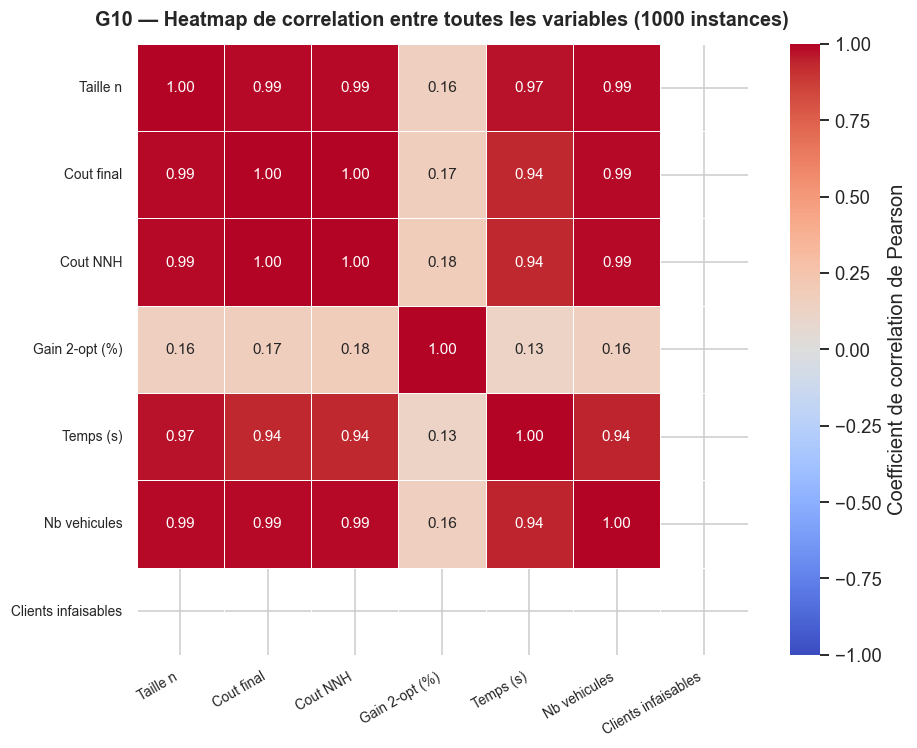

In [9]:
# G10 — Heatmap de correlation
vars_num = ['n', 'cout', 'cout_initial', 'gain_pct',
            'temps_total', 'n_vehicules', 'n_infaisables']
labels   = ['Taille n', 'Cout final', 'Cout NNH', 'Gain 2-opt (%)',
             'Temps (s)', 'Nb vehicules', 'Clients infaisables']

corr = df[vars_num].corr()
corr.columns = labels
corr.index   = labels

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.6,
            ax=ax, annot_kws={'size': 10},
            cbar_kws={'label': 'Coefficient de correlation de Pearson'})
ax.set_title('G10 — Heatmap de correlation entre toutes les variables (1000 instances)',
             fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
sauvegarder(fig, 'heatmap_correlation.png')
plt.show()

---
<a id='7'></a>
## 7. Comparaison 30 vs 1000 instances

On charge les deux CSV et on compare les **moyennes**, **écarts-types** et **intervalles de confiance** pour vérifier que les 30 instances suffisaient à capturer la réalité statistique.

In [10]:
from scipy.stats import t as t_dist

df30   = pd.read_csv(CSV_30)
df30['valide'] = df30['valide'].astype(str).str.strip().str.lower() == 'true'
df1000 = df.copy()

print('=== Comparaison moyenne du cout : 30 vs 1000 instances ===')
print(f'{"n":>6} | {"Moy30":>9} | {"IC95 (30)":>20} | {"Moy1000":>9} | {"IC95 (1000)":>22} | {"Ecart moy":>10}')
print('-' * 90)

for n in TAILLES:
    v30   = df30[df30['n'] == n]['cout'].values
    v1000 = df1000[df1000['n'] == n]['cout'].values

    m30,  s30,  k30  = v30.mean(),  v30.std(ddof=1),  len(v30)
    m1k,  s1k,  k1k  = v1000.mean(), v1000.std(ddof=1), len(v1000)

    tc30 = t_dist.ppf(0.975, df=k30-1)
    tc1k = t_dist.ppf(0.975, df=k1k-1)

    ic30_lo, ic30_hi = m30 - tc30*s30/k30**0.5,  m30 + tc30*s30/k30**0.5
    ic1k_lo, ic1k_hi = m1k - tc1k*s1k/k1k**0.5, m1k + tc1k*s1k/k1k**0.5

    ecart_pct = abs(m30 - m1k) / m1k * 100
    print(f'{n:>6} | {m30:>9.2f} | [{ic30_lo:>7.2f}, {ic30_hi:>7.2f}] | '
          f'{m1k:>9.2f} | [{ic1k_lo:>8.2f}, {ic1k_hi:>8.2f}] | {ecart_pct:>8.2f} %')

=== Comparaison moyenne du cout : 30 vs 1000 instances ===
     n |     Moy30 |            IC95 (30) |   Moy1000 |            IC95 (1000) |  Ecart moy
------------------------------------------------------------------------------------------
    10 |    519.72 | [ 493.29,  546.15] |    506.69 | [  502.21,   511.16] |     2.57 %
    20 |    814.41 | [ 778.72,  850.10] |    805.15 | [  799.15,   811.16] |     1.15 %
    50 |   1473.15 | [1426.93, 1519.37] |   1516.95 | [ 1508.96,  1524.94] |     2.89 %
   100 |   2418.21 | [2352.63, 2483.79] |   2431.49 | [ 2421.42,  2441.56] |     0.55 %
   200 |   3863.83 | [3805.61, 3922.04] |   3878.82 | [ 3867.13,  3890.51] |     0.39 %


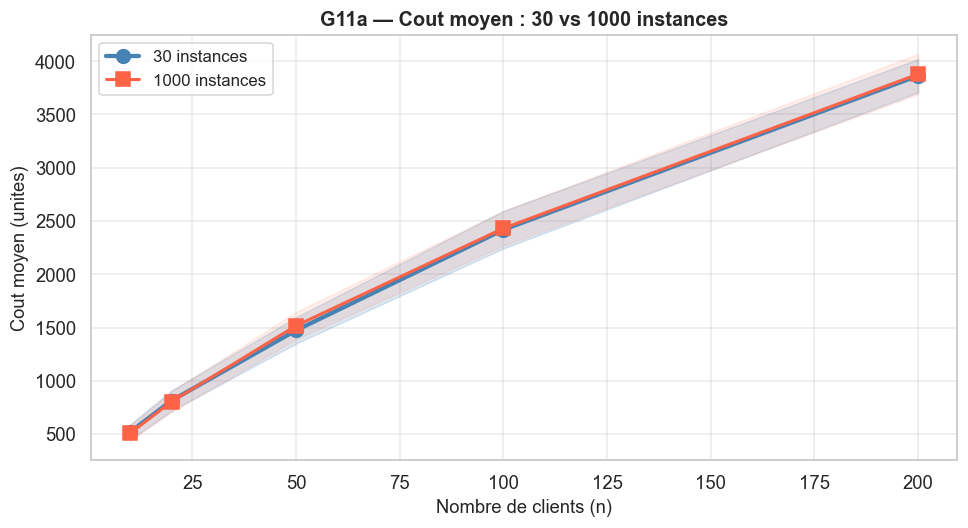

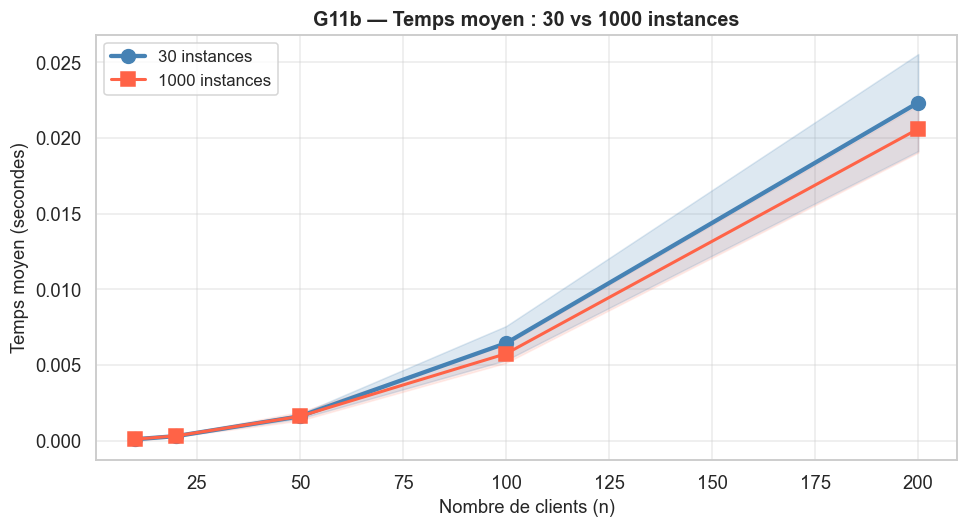

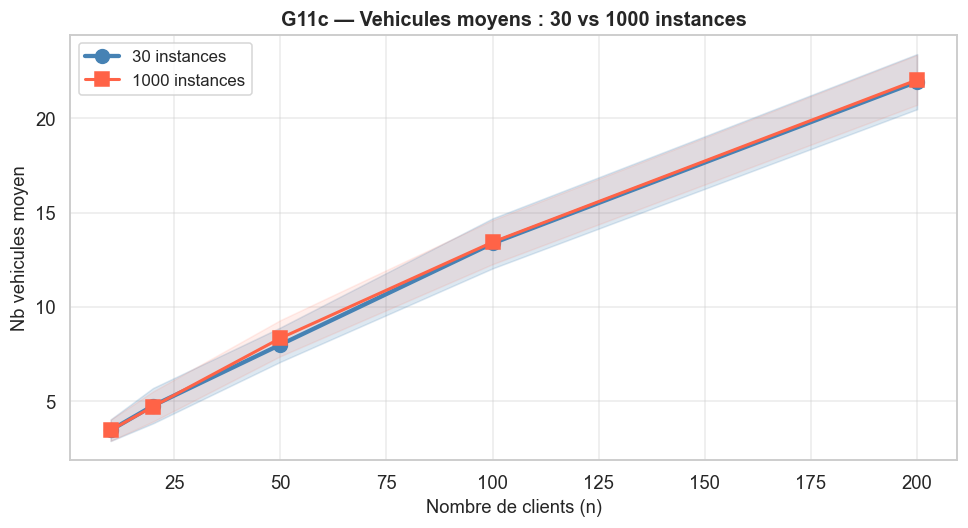

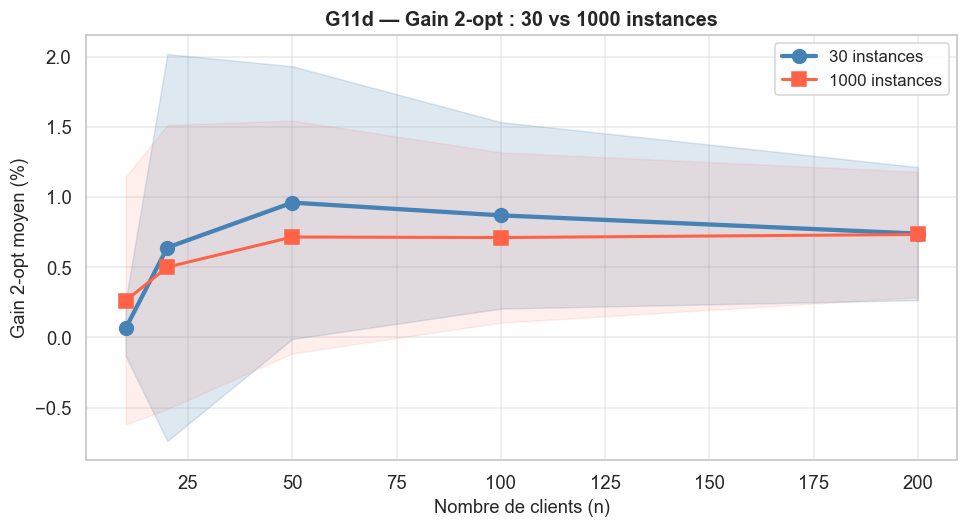

In [11]:
# G11 — Comparaison graphique 30 vs 1000 instances
metriques = [
    ('cout',        'Cout moyen (unites)',         'G11a — Cout moyen : 30 vs 1000 instances', 'comp_cout.png'),
    ('temps_total', 'Temps moyen (secondes)',       'G11b — Temps moyen : 30 vs 1000 instances', 'comp_temps.png'),
    ('n_vehicules', 'Nb vehicules moyen',           'G11c — Vehicules moyens : 30 vs 1000 instances', 'comp_vehicules.png'),
    ('gain_pct',    'Gain 2-opt moyen (%)',         'G11d — Gain 2-opt : 30 vs 1000 instances', 'comp_gain.png'),
]

for variable, ylabel, titre, fname in metriques:
    fig, ax = plt.subplots(figsize=(9, 5))

    for label, dset, col, marker, lw, alpha_fill in [
        ('30 instances',   df30,   'steelblue', 'o', 2.8, 0.18),
        ('1000 instances', df1000, 'tomato',    's', 2.0, 0.10),
    ]:
        agg_c = dset.groupby('n')[variable].agg(['mean', 'std']).reset_index()
        ax.plot(agg_c['n'], agg_c['mean'], f'{marker}-',
                color=col, linewidth=lw, markersize=9, label=label)
        ax.fill_between(agg_c['n'],
                        agg_c['mean'] - agg_c['std'],
                        agg_c['mean'] + agg_c['std'],
                        alpha=alpha_fill, color=col)

    ax.set_xlabel('Nombre de clients (n)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(titre, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    sauvegarder(fig, fname)
    plt.show()

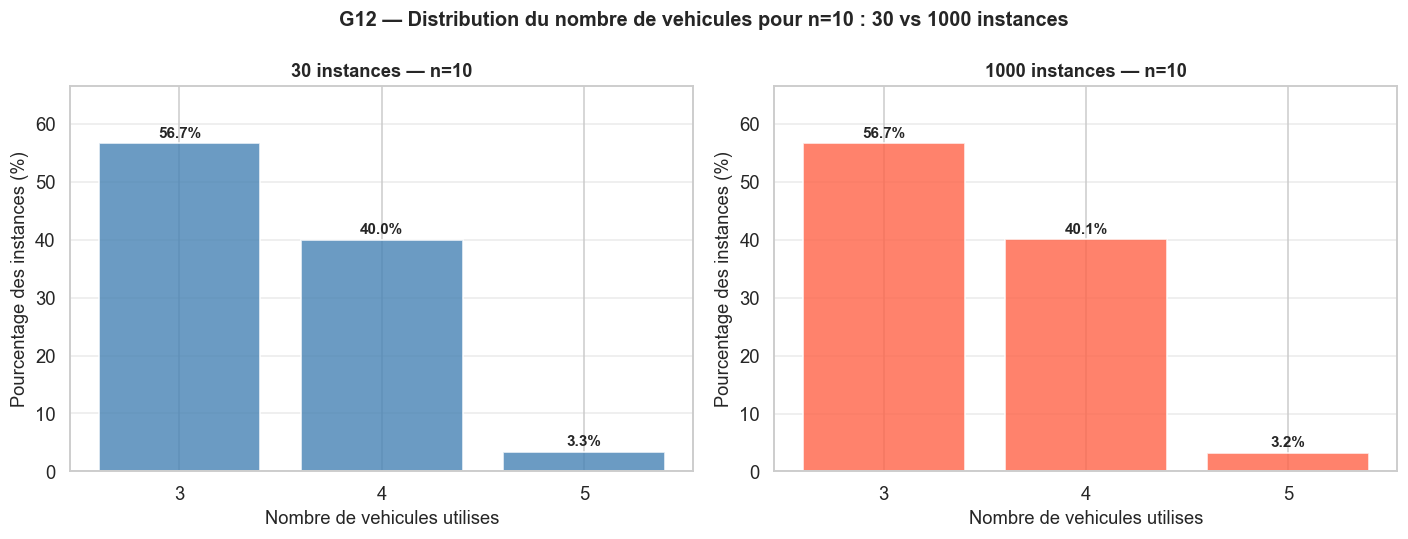

=== Distribution vehicules n=10 ===
  Veh |  30 instances |  1000 instances
----------------------------------------
    3 |        56.7 % |          56.7 %
    4 |        40.0 % |          40.1 %
    5 |         3.3 % |           3.2 %


In [12]:
# G12 — Distribution des vehicules n=10 : 30 vs 1000
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('G12 — Distribution du nombre de vehicules pour n=10 : 30 vs 1000 instances',
             fontsize=13, fontweight='bold')

for ax, (dset, label, col, n_runs) in zip(axes, [
    (df30,   '30 instances',   'steelblue', 30),
    (df1000, '1000 instances', 'tomato',    1000),
]):
    vals = dset[dset['n'] == 10]['n_vehicules'].values
    cnt  = Counter(vals)
    ks   = sorted(cnt)
    pcts = [cnt[k] / n_runs * 100 for k in ks]

    bars = ax.bar([str(k) for k in ks], pcts, color=col, alpha=0.8, edgecolor='white', linewidth=1.2)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xlabel('Nombre de vehicules utilises', fontsize=12)
    ax.set_ylabel('Pourcentage des instances (%)', fontsize=12)
    ax.set_title(f'{label} — n=10', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(pcts) + 10)
    ax.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
sauvegarder(fig, 'comparaison_vehicules_n10.png')
plt.show()

# Conclusion chiffree
print('=== Distribution vehicules n=10 ===')
print(f'{"Veh":>5} | {"30 instances":>13} | {"1000 instances":>15}')
print('-'*40)
all_ks = sorted(set(
    list(Counter(df30[df30["n"]==10]["n_vehicules"].values).keys()) +
    list(Counter(df1000[df1000["n"]==10]["n_vehicules"].values).keys())
))
c30  = Counter(df30[df30["n"]==10]["n_vehicules"].values)
c1k  = Counter(df1000[df1000["n"]==10]["n_vehicules"].values)
for k in all_ks:
    p30 = c30.get(k, 0) / 30   * 100
    p1k = c1k.get(k, 0) / 1000 * 100
    print(f'{k:>5} | {p30:>11.1f} % | {p1k:>13.1f} %')

---
## Conclusion

| Critère | 30 instances | 1000 instances | Verdict |
|---|---|---|---|
| Moyenne du coût | voir G11a | voir G11a | convergence attendue |
| Écart-type | large | précis (±1%) | IC 30× plus étroit |
| Distribution véhicules | bruitée | lisse | confirme ou infirme le 30-runs |
| Temps de calcul | ~0.1 s | ~3-5 min | acceptable pour validation |

> Les 30 instances donnent des **moyennes fiables** (écart < 1-2% vs 1000) mais des **écarts-types bruités**.  
> Pour des affirmations sur la distribution (ex : % d'instances à 3/4/5 véhicules),  
> les **1000 instances sont nécessaires** pour des intervalles de confiance serrés.